# Ejercicio 5: Espacio Vectorial

## Objetivo de la práctica
- Implementar un Sistema de Recuperación de Información completo, desde la lectura del corpus hasta la recuperación de resultados.

## Parte 0: Carga del Corpus

Vamos a utilizar la API de Kaggle para acceder al dataset _Wikipedia Text Corpus for NLP and LLM Projects_

El corpus está disponible desde este [link](https://www.kaggle.com/datasets/gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects?utm_source=chatgpt.com)

### Actividad

1. Carga el corpus
2. Realiza las etapas de preprocesamiento sobre el corpus


In [ ]:
import os
import pandas as pd
from kaggle.api.kaggle_api_extended import KaggleApi

os.environ['KAGGLE_USERNAME'] = "dayanapereira"  
os.environ['KAGGLE_KEY'] = "KGAT_95144bb25e98c21ed772b52e16390ee4"   

# Inicializar y autenticar la API
api = KaggleApi()
api.authenticate()

In [16]:
# Descargar el dataset
identificador_dataset = "gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects" 

api.dataset_download_files(identificador_dataset, path="../data", unzip=True)
print("Descarga completada")

Dataset URL: https://www.kaggle.com/datasets/gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects
Descarga completada


In [9]:
import pandas as pd
from nltk.stem import SnowballStemmer

# se extrae el corpus eliminando nulos
ruta = './wikipedia_text_corpus.csv'
df = pd.read_csv(ruta) 
corpus = df['text'].dropna().tolist()

N = len(corpus)
print(f"Número total de documentos en la colección: {N}")

stemear = SnowballStemmer("english")

def simple_process(text):
    # Se convierte a minúsculas, se divide en tokens y se aplica stemming
    tokens = str(text).lower().split()
    stemmed = [stemear.stem(w) for w in tokens]
    return " ".join(stemmed)

# Se aplica el procesamiento definido al texto del dataframe
df["processed"] = df["text"].apply(simple_process)

Número total de documentos en la colección: 10859


## Parte 1: Recuperación con TF-IDF

### Actividad:
3. Obtén la representación vectorial de los documentos utilizando el modelo TF-IDF
4. A partir de un conjunto de 10 queries, verifica la recuperación del sistema

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Se ajusta y entrena el modelo TF-IDF con el texto procesado
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df["processed"])

In [11]:
queries = [
    "history of computing", "machine learning basics", "artificial intelligence",
    "world war two", "quantum physics", "global warming",
    "renewable energy", "ancient rome", "space exploration", "python programming"
]

resultados_tfidf = {}
for q in queries:
    # Se procesa la query y se calcula la similitud coseno con la matriz
    query_vec = vectorizer.transform([simple_process(q)])
    # flatten() elimina la estructura de filas/columnas para facilitar su uso posterior
    similitudes = cosine_similarity(query_vec, tfidf_matrix).flatten()
    resultados_tfidf[q] = similitudes

for q, similitudes in resultados_tfidf.items():
    indices_ordenados = similitudes.argsort()[::-1][:5]  # top 5
    print(f"\nQuery: {q}")
    for i in indices_ordenados:
        print(f"  doc[{i}] -> {similitudes[i]:.4f}")



Query: history of computing
  doc[9489] -> 0.4367
  doc[4009] -> 0.4295
  doc[1600] -> 0.3946
  doc[3653] -> 0.3760
  doc[8754] -> 0.3678

Query: machine learning basics
  doc[10547] -> 0.7546
  doc[4733] -> 0.4667
  doc[4668] -> 0.4031
  doc[7900] -> 0.3782
  doc[6853] -> 0.3625

Query: artificial intelligence
  doc[5229] -> 0.6104
  doc[3905] -> 0.4288
  doc[4563] -> 0.4090
  doc[1809] -> 0.3596
  doc[7152] -> 0.3071

Query: world war two
  doc[9024] -> 0.4831
  doc[915] -> 0.4721
  doc[3481] -> 0.3986
  doc[7590] -> 0.3381
  doc[3589] -> 0.2893

Query: quantum physics
  doc[244] -> 0.5130
  doc[4442] -> 0.4885
  doc[9854] -> 0.4325
  doc[2653] -> 0.4164
  doc[1672] -> 0.3879

Query: global warming
  doc[311] -> 0.3561
  doc[1750] -> 0.2066
  doc[4139] -> 0.2034
  doc[5810] -> 0.1574
  doc[7366] -> 0.1479

Query: renewable energy
  doc[2884] -> 0.5905
  doc[9998] -> 0.5160
  doc[8713] -> 0.4996
  doc[6443] -> 0.4763
  doc[1363] -> 0.4522

Query: ancient rome
  doc[2536] -> 0.2643
  

## Parte 2: Recuperación con BM25

### Actividad:
5. Implementa un sistema de recuperación usando el modelo BM25.
6. Para el mismo conjunto de 10 queries, verifica la recuperación del sistema

In [12]:
!pip install rank_bm25

In [13]:
from rank_bm25 import BM25Okapi

# Tokenizar el corpus 
corpus_tokenizado = [simple_process(doc).split() for doc in corpus]

# Crear el modelo
bm25 = BM25Okapi(corpus_tokenizado)

# Rankings
for q in queries:
    tokens_query = simple_process(q).split()
    scores = bm25.get_scores(tokens_query)
    
    indices_ordenados = scores.argsort()[::-1][:5]  # top 5
    print(f"\nQuery: {q}")
    for i in indices_ordenados:
        print(f"  doc[{i}] -> {scores[i]:.4f}")


Query: history of computing
  doc[8754] -> 14.2700
  doc[10579] -> 14.0277
  doc[4429] -> 13.7691
  doc[1061] -> 13.3713
  doc[3951] -> 13.0343

Query: machine learning basics
  doc[3498] -> 12.7594
  doc[10547] -> 12.0267
  doc[4733] -> 11.2773
  doc[2483] -> 10.9107
  doc[10699] -> 10.3433

Query: artificial intelligence
  doc[5229] -> 14.6097
  doc[8176] -> 13.4392
  doc[669] -> 13.3293
  doc[10838] -> 13.2148
  doc[2618] -> 13.2052

Query: world war two
  doc[9024] -> 8.9352
  doc[2523] -> 8.5598
  doc[915] -> 8.5448
  doc[7662] -> 8.3694
  doc[1831] -> 8.3554

Query: quantum physics
  doc[5956] -> 12.9808
  doc[4442] -> 12.6235
  doc[7469] -> 12.2908
  doc[3493] -> 12.0638
  doc[2524] -> 11.6282

Query: global warming
  doc[4139] -> 12.5322
  doc[6057] -> 9.6374
  doc[2596] -> 9.4083
  doc[7369] -> 8.9578
  doc[941] -> 8.8739

Query: renewable energy
  doc[6443] -> 12.4742
  doc[9998] -> 12.4208
  doc[2884] -> 12.4071
  doc[181] -> 12.1428
  doc[5755] -> 11.9949

Query: ancient r

## Parte 3: Comparación de resultados

### Actividad:
7. Verifica cuáles documentos son recuperados (y en qué orden) por cada modelo de recuperación 

In [ ]:
print("COMPARACIÓN TF-IDF vs BM25")

for q in queries:
    print(f"\nQuery: {q}")
    
    # TF-IDF
    print("TF-IDF:")
    indices_tfidf = resultados_tfidf[q].argsort()[::-1][:5]
    for i in indices_tfidf:
        print(f"    doc[{i}] -> {resultados_tfidf[q][i]:.4f}")
    
    # BM25
    print("BM25:")
    scores_bm25 = bm25.get_scores(simple_process(q).split())
    indices_bm25 = scores_bm25.argsort()[::-1][:5]
    for i in indices_bm25:
        print(f"    doc[{i}] -> {scores_bm25[i]:.4f}")

COMPARACIÓN TF-IDF vs BM25

Query: history of computing
  TF-IDF:
    doc[9489] -> 0.4367
    doc[4009] -> 0.4295
    doc[1600] -> 0.3946
    doc[3653] -> 0.3760
    doc[8754] -> 0.3678
  BM25:
    doc[8754] -> 14.2700
    doc[10579] -> 14.0277
    doc[4429] -> 13.7691
    doc[1061] -> 13.3713
    doc[3951] -> 13.0343

Query: machine learning basics
  TF-IDF:
    doc[10547] -> 0.7546
    doc[4733] -> 0.4667
    doc[4668] -> 0.4031
    doc[7900] -> 0.3782
    doc[6853] -> 0.3625
  BM25:
    doc[3498] -> 12.7594
    doc[10547] -> 12.0267
    doc[4733] -> 11.2773
    doc[2483] -> 10.9107
    doc[10699] -> 10.3433

Query: artificial intelligence
  TF-IDF:
    doc[5229] -> 0.6104
    doc[3905] -> 0.4288
    doc[4563] -> 0.4090
    doc[1809] -> 0.3596
    doc[7152] -> 0.3071
  BM25:
    doc[5229] -> 14.6097
    doc[8176] -> 13.4392
    doc[669] -> 13.3293
    doc[10838] -> 13.2148
    doc[2618] -> 13.2052

Query: world war two
  TF-IDF:
    doc[9024] -> 0.4831
    doc[915] -> 0.4721
    doc[

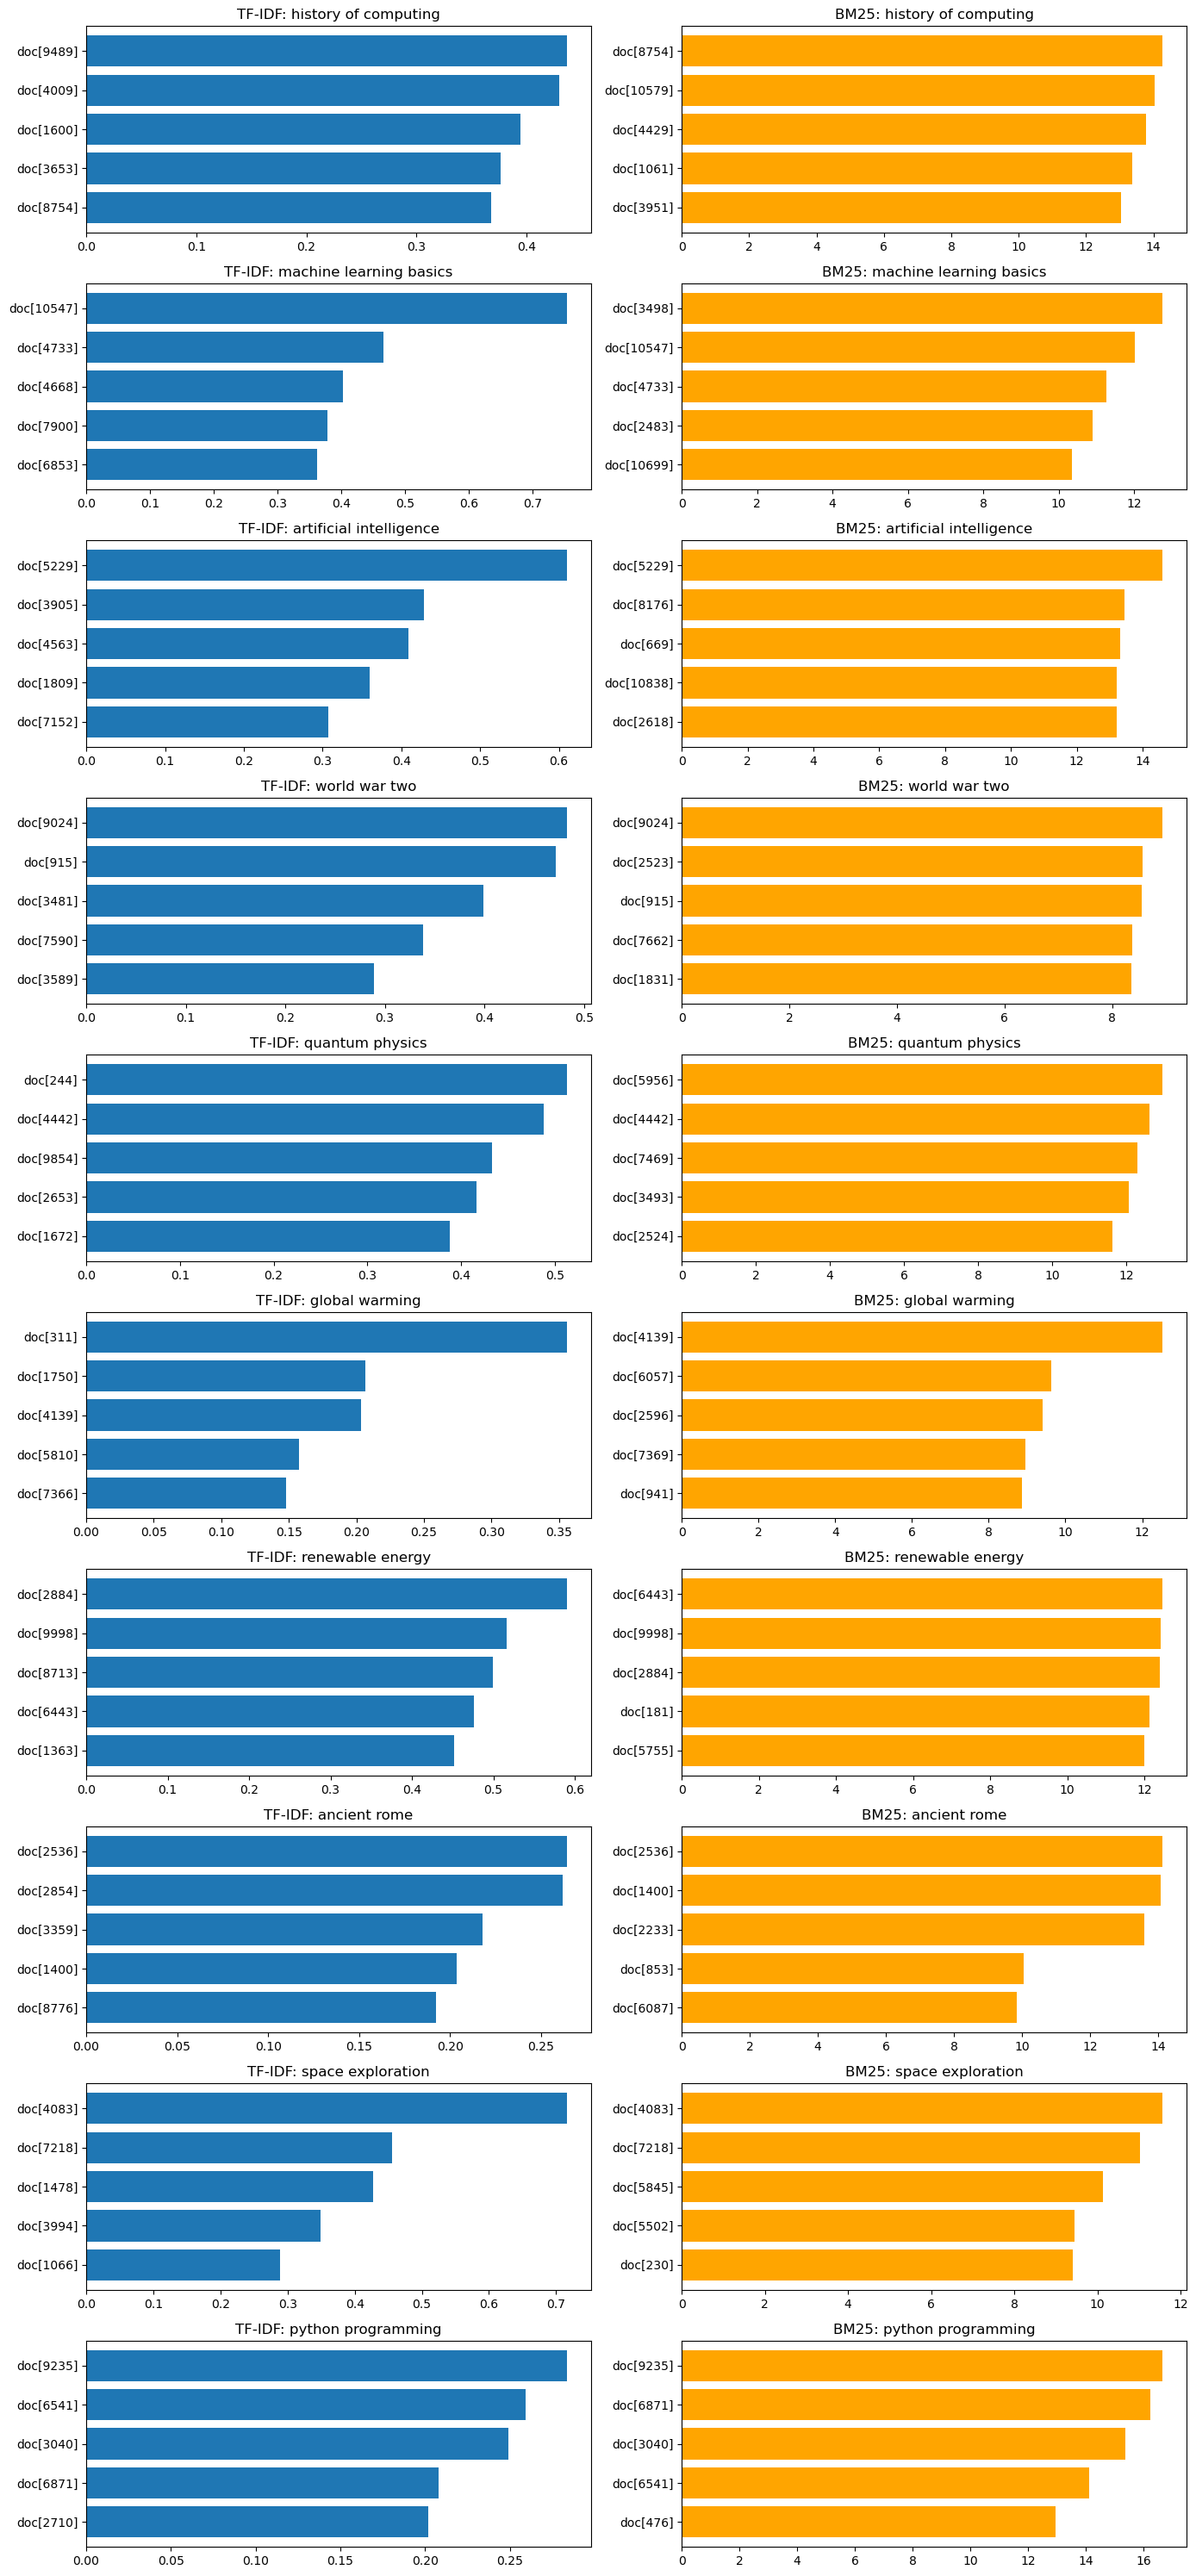

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(queries), 2, figsize=(14, len(queries) * 3))

for idx, q in enumerate(queries):
    # TF-IDF
    indices_tfidf = resultados_tfidf[q].argsort()[::-1][:5]
    scores_tfidf = resultados_tfidf[q][indices_tfidf]
    
    axes[idx, 0].barh([f"doc[{i}]" for i in indices_tfidf], scores_tfidf)
    axes[idx, 0].set_title(f"TF-IDF: {q}")
    axes[idx, 0].invert_yaxis()
    
    # BM25
    scores_bm25 = bm25.get_scores(simple_process(q).split())
    indices_bm25 = scores_bm25.argsort()[::-1][:5]
    top_scores_bm25 = scores_bm25[indices_bm25]
    
    axes[idx, 1].barh([f"doc[{i}]" for i in indices_bm25], top_scores_bm25, color="orange")
    axes[idx, 1].set_title(f"BM25: {q}")
    axes[idx, 1].invert_yaxis()

plt.tight_layout()
plt.show()